# フィジカルAI関連銘柄 横並び比較

**対象5銘柄（東証上場）**
- ソニーグループ（6758）：CMOSイメージセンサー世界1位、Nihon AI Kiban参画
- キーエンス（6861）：FAセンサー・マシンビジョン、営業利益率約50%
- ファナック（6954）：産業用ロボット・CNC世界トップ
- ナブテスコ（6268）：中大型ロボット関節用精密減速機、世界シェアトップ
- ハーモニック・ドライブ（6324）：ヒューマノイド関節用波動歯車装置

**評価軸**：フィジカルAI純度 / 最大手か / チョークポイント / バリュエーション

---

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, logging

warnings.filterwarnings('ignore')
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['MS Gothic', 'Meiryo', 'Yu Gothic', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

fx = yf.Ticker('USDJPY=X').history(period='1d')
USDJPY = float(fx['Close'].iloc[-1]) if not fx.empty else 155.0
print(f'USDJPY: {USDJPY:.2f}')

TICKERS = {
    '6758.T': 'ソニーグループ',
    '6861.T': 'キーエンス',
    '6954.T': 'ファナック',
    '6268.T': 'ナブテスコ',
    '6324.T': 'ハーモニック・ドライブ',
}

COLORS = {
    '6758.T': '#E53935',
    '6861.T': '#1E88E5',
    '6954.T': '#43A047',
    '6268.T': '#FB8C00',
    '6324.T': '#8E24AA',
}

USDJPY: 157.77


## 1. 基本財務データ

In [2]:
rows = []
info_cache = {}

for ticker, name in TICKERS.items():
    info = yf.Ticker(ticker).info
    info_cache[ticker] = info

    price  = info.get('currentPrice') or info.get('regularMarketPrice', 0)
    mcap   = info.get('marketCap', None)
    pe_tr  = info.get('trailingPE', None)
    pe_fw  = info.get('forwardPE', None)
    om     = info.get('operatingMargins', None)
    rev    = info.get('totalRevenue', None)
    rev_g  = info.get('revenueGrowth', None)
    eps_tr = info.get('trailingEps', None)

    rows.append({
        '銘柄':        f'{name}\n({ticker.replace(".T","")})',
        '株価（円）':   f'{price:,.0f}',
        '時価総額':    f'~¥{mcap/1e12:.1f}兆 (~${mcap/USDJPY/1e9:.0f}B)' if mcap else 'N/A',
        'Trailing EPS': f'¥{eps_tr:,.0f}' if eps_tr else 'N/A',
        'Trailing PER': f'{pe_tr:.1f}x' if pe_tr else 'N/A',
        'Forward PER':  f'{pe_fw:.1f}x' if pe_fw else 'N/A',
        '営業利益率':   f'{om*100:.1f}%' if om else 'N/A',
        '売上成長率':   f'{rev_g*100:+.1f}%' if rev_g else 'N/A',
    })

df_basic = pd.DataFrame(rows).set_index('銘柄')
print('5銘柄 基本財務データ')
df_basic

5銘柄 基本財務データ


,株価（円）,時価総額,Trailing EPS,Trailing PER,Forward PER,営業利益率,売上成長率
銘柄,,,,,,,
ソニーグループ\n(6758),"3,660",~¥21.6兆 (~$137B),¥171,21.4x,20.0x,7.6%,+15.4%
キーエンス\n(6861),"79,440",~¥19.3兆 (~$122B),"¥1,839",43.2x,42.5x,53.6%,+17.9%
ファナック\n(6954),"7,680",~¥7.2兆 (~$45B),¥178,43.1x,44.4x,23.9%,+10.6%
ナブテスコ\n(6268),"5,737",~¥0.7兆 (~$4B),¥124,46.2x,53.2x,9.9%,+1.6%
ハーモニック・ドライブ\n(6324),"6,970",~¥0.7兆 (~$4B),¥49,142.7x,92.1x,5.1%,N/A


## 2. 株価パフォーマンス比較（過去3年）

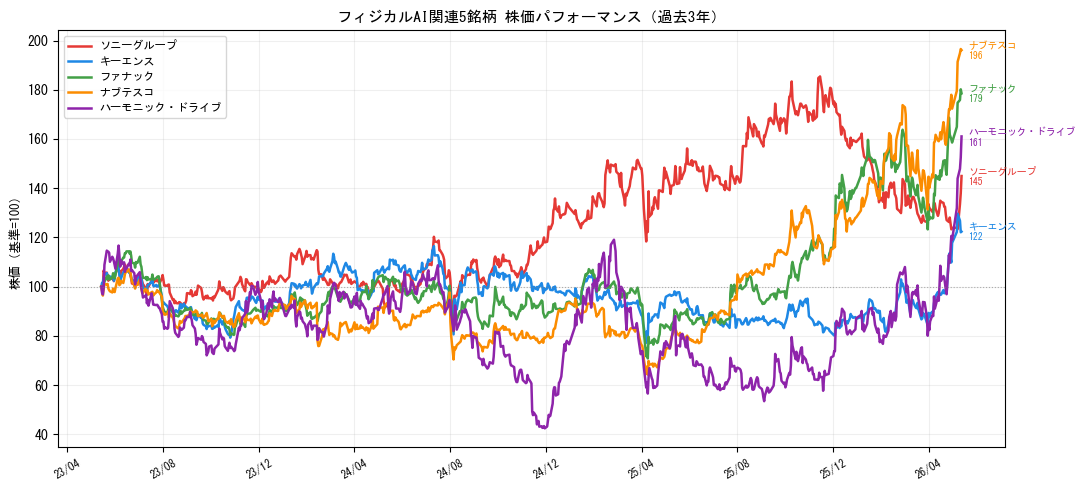

In [3]:
hist = {}
for ticker in TICKERS:
    df = yf.Ticker(ticker).history(period='3y')
    if not df.empty:
        s = df['Close'].copy()
        s.index = pd.to_datetime(s.index).tz_localize(None)
        hist[ticker] = s

fig, ax = plt.subplots(figsize=(11, 5))

for ticker, name in TICKERS.items():
    if ticker in hist:
        s = hist[ticker]
        norm = s / s.iloc[0] * 100
        ax.plot(norm.index, norm.values, label=name, color=COLORS[ticker], linewidth=1.8)
        # 末尾にラベル
        ax.annotate(f'{name}\n{norm.iloc[-1]:.0f}',
                    xy=(norm.index[-1], norm.iloc[-1]),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=7, color=COLORS[ticker], va='center')

ax.axhline(100, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.set_ylabel('株価（基準=100）', fontsize=9)
ax.set_title('フィジカルAI関連5銘柄 株価パフォーマンス（過去3年）', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.grid(True, alpha=0.2)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
# 期間別リターン
periods = {'1ヶ月': '1mo', '3ヶ月': '3mo', '1年': '1y', '3年': '3y'}
ret_rows = []

for ticker, name in TICKERS.items():
    row = {'銘柄': name}
    for label, period in periods.items():
        df = yf.Ticker(ticker).history(period=period)
        if not df.empty:
            ret = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
            row[label] = f'{ret:+.1f}%'
        else:
            row[label] = 'N/A'
    ret_rows.append(row)

df_ret = pd.DataFrame(ret_rows).set_index('銘柄')
print('期間別リターン')
df_ret

期間別リターン


,1ヶ月,3ヶ月,1年,3年
銘柄,,,,
ソニーグループ,+12.6%,+3.4%,+0.9%,+45.0%
キーエンス,+25.1%,+43.6%,+24.8%,+22.4%
ファナック,+24.2%,+20.3%,+96.9%,+78.5%
ナブテスコ,+23.1%,+28.6%,+134.0%,+96.1%
ハーモニック・ドライブ,+67.7%,+92.8%,+84.6%,+61.0%


## 3. バリュエーション比較：PER × 営業利益率

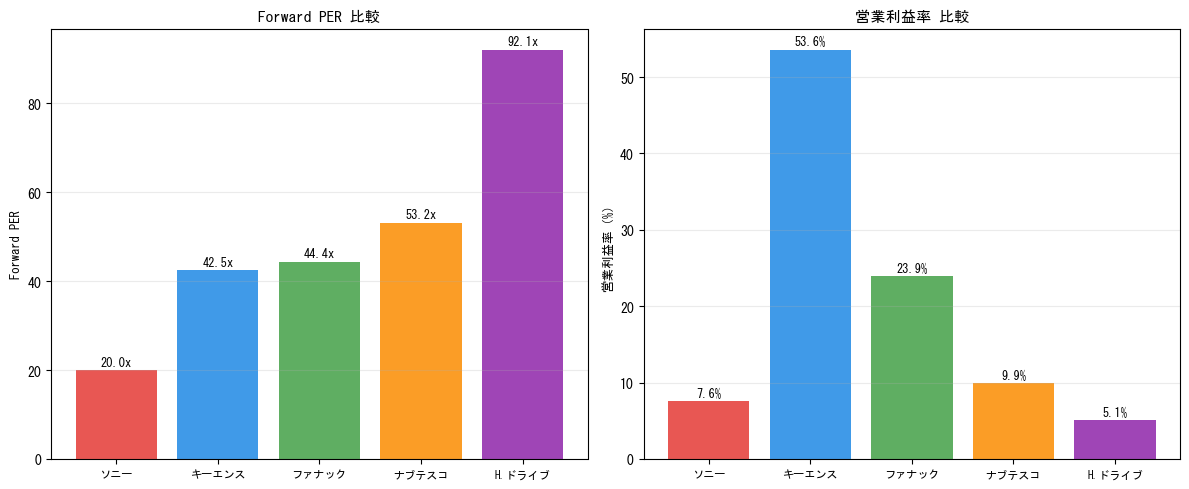

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names_short = [TICKERS[t].replace('グループ', '').replace('ハーモニック・', 'H.') for t in TICKERS]
ticker_list = list(TICKERS.keys())
color_list  = [COLORS[t] for t in ticker_list]

# 左：Forward PER
ax = axes[0]
fpe_vals = []
for t in ticker_list:
    v = info_cache[t].get('forwardPE', None)
    fpe_vals.append(v if v else 0)

bars = ax.bar(names_short, fpe_vals, color=color_list, alpha=0.85)
for bar, val in zip(bars, fpe_vals):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Forward PER', fontsize=9)
ax.set_title('Forward PER 比較', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.25, axis='y')

# 右：営業利益率
ax2 = axes[1]
om_vals = []
for t in ticker_list:
    v = info_cache[t].get('operatingMargins', None)
    om_vals.append(v * 100 if v else 0)

bars2 = ax2.bar(names_short, om_vals, color=color_list, alpha=0.85)
for bar, val in zip(bars2, om_vals):
    if val:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('営業利益率（%）', fontsize=9)
ax2.set_title('営業利益率 比較', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', labelsize=8)
ax2.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

## 4. 総合評価マトリクス

定性評価（レポート記載内容ベース）を定量スコアに変換して5軸レーダーチャートで比較。

| 評価軸 | 定義 |
|---|---|
| フィジカルAI純度 | 売上・事業のどれだけがフィジカルAIに直結するか |
| 最大手度 | その領域でのグローバル市場シェア・地位 |
| チョークポイント | 代替困難性・参入障壁の高さ |
| バリュエーション妥当性 | PER・利益率から見た割安感（高いほど割安） |
| 成長カタリスト | 1〜3年でヒューマノイド量産の恩恵を受ける直接度 |

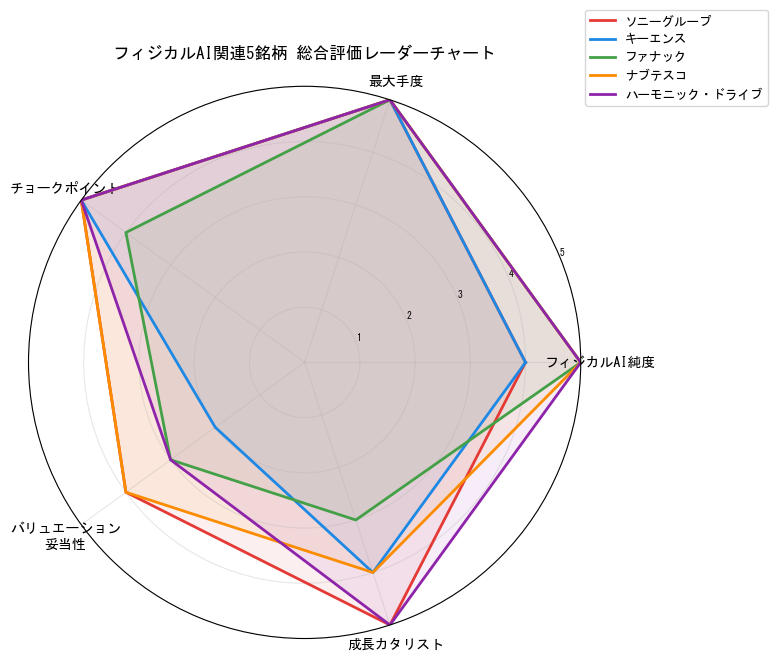

In [6]:
# 定性スコア（5点満点、レポート記載内容ベース）
scores = {
    'ソニーグループ': {
        'フィジカルAI純度':    4,  # I&SS 17%、ゲーム・音楽も大きい
        '最大手度':           5,  # センサー世界シェア43%
        'チョークポイント':    5,  # EVS・積層型CMOS、代替なし
        'バリュエーション妥当性': 4,  # PER22倍、I&SSはまだ割安
        '成長カタリスト':     5,  # Nihon AI Kiban・TSMC合弁・Ace
    },
    'キーエンス': {
        'フィジカルAI純度':    4,  # FAセンサー・マシンビジョン専業
        '最大手度':           5,  # 世界トップ、営業利益率50%
        'チョークポイント':    5,  # ロボットの「目」を独占供給
        'バリュエーション妥当性': 2,  # 高PER、割高感あり
        '成長カタリスト':     4,  # ロボット普及で需要増は直接的
    },
    'ファナック': {
        'フィジカルAI純度':    5,  # 産業ロボット・CNC専業
        '最大手度':           5,  # 世界トップ
        'チョークポイント':    4,  # FA自動化の中枢、競合はあり
        'バリュエーション妥当性': 3,  # 中程度
        '成長カタリスト':     3,  # 産業用中心、ヒューマノイド直結は薄い
    },
    'ナブテスコ': {
        'フィジカルAI純度':    5,  # 精密減速機専業
        '最大手度':           5,  # 中大型ロボット用で世界トップ
        'チョークポイント':    5,  # 関節なしにロボットは動かない
        'バリュエーション妥当性': 4,  # 比較的割安
        '成長カタリスト':     4,  # ロボット量産で直接恩恵
    },
    'ハーモニック・ドライブ': {
        'フィジカルAI純度':    5,  # ヒューマノイド関節専業
        '最大手度':           5,  # 波動歯車で世界トップ
        'チョークポイント':    5,  # ヒューマノイドに必須、代替困難
        'バリュエーション妥当性': 3,  # 小型株、成長期待でやや高め
        '成長カタリスト':     5,  # ヒューマノイド量産の最直接受益
    },
}

axes_labels = ['フィジカルAI純度', '最大手度', 'チョークポイント', 'バリュエーション\n妥当性', '成長カタリスト']
N = len(axes_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, sc in scores.items():
    ticker = [t for t, n in TICKERS.items() if n == name][0]
    values = [sc[l.replace('\n', '')] for l in axes_labels]
    values += values[:1]
    ax.plot(angles, values, color=COLORS[ticker], linewidth=2, label=name)
    ax.fill(angles, values, color=COLORS[ticker], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(axes_labels, fontsize=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=7)
ax.set_title('フィジカルAI関連5銘柄 総合評価レーダーチャート', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# 総合スコア表
score_rows = []
for name, sc in scores.items():
    total = sum(sc.values())
    row = {'銘柄': name}
    row.update({k: f'{v}/5' for k, v in sc.items()})
    row['合計'] = f'{total}/25'
    score_rows.append(row)

df_score = pd.DataFrame(score_rows).set_index('銘柄')
df_score

,フィジカルAI純度,最大手度,チョークポイント,バリュエーション妥当性,成長カタリスト,合計
銘柄,,,,,,
ソニーグループ,4/5,5/5,5/5,4/5,5/5,23/25
キーエンス,4/5,5/5,5/5,2/5,4/5,20/25
ファナック,5/5,5/5,4/5,3/5,3/5,20/25
ナブテスコ,5/5,5/5,5/5,4/5,4/5,23/25
ハーモニック・ドライブ,5/5,5/5,5/5,3/5,5/5,23/25


## 5. 時価総額スケール比較

ハーモニック・ドライブのような小型株は、同じ需要増でもより大きな株価インパクトが出やすい。

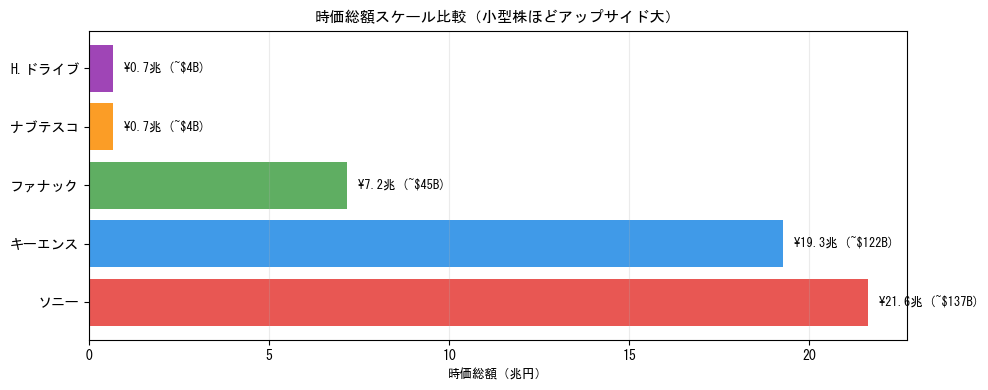

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

mcap_vals = []
name_list = []
for ticker, name in TICKERS.items():
    mcap = info_cache[ticker].get('marketCap', 0)
    mcap_vals.append(mcap / 1e12)  # 兆円
    name_list.append(name.replace('グループ', '').replace('ハーモニック・', 'H.'))

bars = ax.barh(name_list, mcap_vals, color=color_list, alpha=0.85)
for bar, val in zip(bars, mcap_vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'¥{val:.1f}兆 (~${val*1e12/USDJPY/1e9:.0f}B)',
            va='center', fontsize=9)

ax.set_xlabel('時価総額（兆円）', fontsize=9)
ax.set_title('時価総額スケール比較（小型株ほどアップサイド大）', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.25, axis='x')
plt.tight_layout()
plt.show()

## 6. 投資判断サマリー

| 銘柄 | 位置づけ | バケット候補 | 理由 |
|---|---|---|---|
| **ソニー（6758）** | 本命・主力 | 運用枠 | センサー世界1位×政府支援×PER割安 |
| **ハーモニック・ドライブ（6324）** | 高純度・小型 | リスク枠 | ヒューマノイド量産の最直接受益、小型株ゆえの上振れ余地 |
| **ナブテスコ（6268）** | チョークポイント型 | 運用枠候補 | 中大型ロボット関節で世界トップ、安定感あり |
| **ファナック（6954）** | 安定大型 | 運用枠候補 | 産業ロボット世界トップだが、ヒューマノイド直結は薄め |
| **キーエンス（6861）** | 超高品質・割高 | — | モートは最強クラスだがバリュエーションが重い |
